# Video 17a1: Exploratory Data Analysis - Understanding Our COX-2 Dataset
Explanation Script:
"Before building any machine learning models, we need to understand our data thoroughly. Exploratory Data Analysis or EDA helps us see patterns, spot issues, and guide our modeling decisions. We'll examine the structure of our COX-2 dataset, the distribution of pIC50 values, and the balance between active and inactive compounds."

COX-2 DATASET EXPLORATORY DATA ANALYSIS

1. DATASET OVERVIEW
----------------------------------------
Total molecules: 5371
Total columns: 1029
Fingerprint bits: 1024
ID/Target columns: ['molecule_chembl_id', 'standard_value', 'pIC50', 'active', 'activity_class']

2. DATA TYPES
----------------------------------------


,Column,Data Type
0,molecule_chembl_id,object
1,standard_value,float64
2,pIC50,float64
3,active,int64
4,activity_class,object
5,fp_0,int64
6,fp_1,int64
7,fp_2,int64
8,fp_3,int64
9,fp_4,int64



3. SUMMARY STATISTICS (pIC50 and standard_value)
----------------------------------------


,standard_value,pIC50
count,5.371000e+03,5371.00
mean,2.132328e+05,5.82
std,4.828811e+06,1.32
min,1.000000e-02,0.65
25%,1.592400e+02,4.89
50%,1.600000e+03,5.80
75%,1.300000e+04,6.80
max,2.233420e+08,11.22



4. MISSING VALUES CHECK
----------------------------------------


...


5. FIRST 5 ROWS
----------------------------------------


,molecule_chembl_id,standard_value,pIC50,active,activity_class,fp_0,fp_1,fp_2,fp_3,fp_4,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
0,CHEMBL100091,60.0,7.22,1,Active,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,CHEMBL100092,60.0,7.22,1,Active,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,CHEMBL100156,4000.0,5.40,0,Inactive,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,CHEMBL100250,4000.0,5.40,0,Inactive,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,CHEMBL100331,40.0,7.40,1,Active,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



6. LAST 5 ROWS
----------------------------------------


,molecule_chembl_id,standard_value,pIC50,active,activity_class,fp_0,fp_1,fp_2,fp_3,fp_4,...,fp_1014,fp_1015,fp_1016,fp_1017,fp_1018,fp_1019,fp_1020,fp_1021,fp_1022,fp_1023
5366,CHEMBL99374,4000.0,5.40,0,Inactive,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5367,CHEMBL99517,13000.0,4.89,0,Inactive,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5368,CHEMBL99727,130000.0,3.89,0,Inactive,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5369,CHEMBL99828,10000.0,5.00,0,Inactive,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5370,CHEMBL99933,100.0,7.00,1,Active,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



7. MEMORY USAGE
----------------------------------------
Total memory: 42.69 MB
Memory per molecule: 8334 bytes


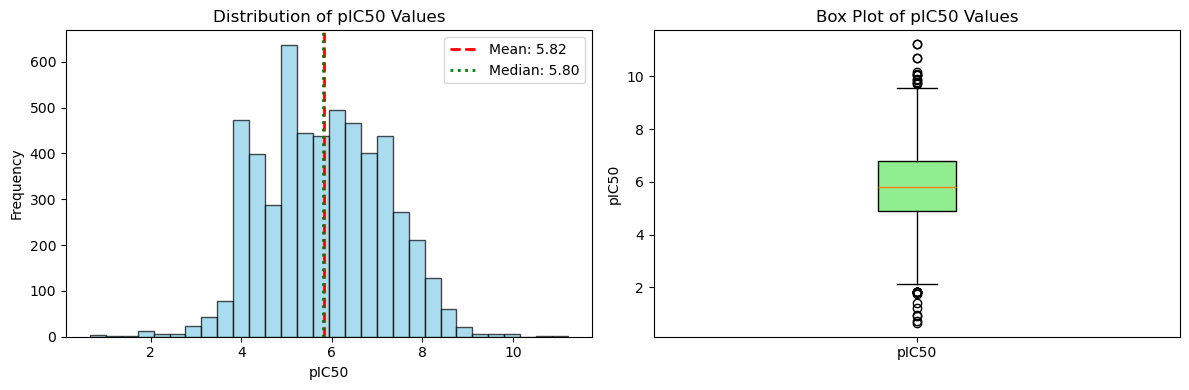


✓ Initial data exploration complete


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load the COX-2 fingerprint dataset
df = pd.read_csv('cox2_chembl_fingerprints.csv')
print("COX-2 DATASET EXPLORATORY DATA ANALYSIS")
print("=" * 70)

# Basic dataset information
print("\n1. DATASET OVERVIEW")
print("-" * 40)
print(f"Total molecules: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"Fingerprint bits: {df.shape[1] - 5}")
print(f"ID/Target columns: {df.columns[:5].tolist()}")

# Data types
print("\n2. DATA TYPES")
print("-" * 40)
dtypes_df = pd.DataFrame({
    'Column': df.dtypes.index[:10],  # First 10 columns
    'Data Type': df.dtypes.values[:10]
})
display(dtypes_df)

# Summary statistics
print("\n3. SUMMARY STATISTICS (pIC50 and standard_value)")
print("-" * 40)
stats_df = df[['standard_value', 'pIC50']].describe().round(2)
display(stats_df)

# Missing values check
print("\n4. MISSING VALUES CHECK")
print("-" * 40)
missing_df = pd.DataFrame({
    'Column': df.columns[:10],  # First 10 columns
    'Non-Null Count': df.count().values[:10],
    'Null Count': df.isnull().sum().values[:10],
    'Null %': (df.isnull().sum().values[:10] / len(df) * 100).round(2)
})
display(missing_df)

# First and last rows
print("\n5. FIRST 5 ROWS")
print("-" * 40)
display(df.head(5))

print("\n6. LAST 5 ROWS")
print("-" * 40)
display(df.tail(5))

# Memory usage
print("\n7. MEMORY USAGE")
print("-" * 40)
memory_bytes = df.memory_usage(deep=True).sum()
memory_mb = memory_bytes / (1024 * 1024)
print(f"Total memory: {memory_mb:.2f} MB")
print(f"Memory per molecule: {memory_bytes / len(df):.0f} bytes")

# Quick visualization of pIC50 distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['pIC50'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['pIC50'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df['pIC50'].mean():.2f}")
axes[0].axvline(df['pIC50'].median(), color='green', linestyle=':', linewidth=2, label=f"Median: {df['pIC50'].median():.2f}")
axes[0].set_xlabel('pIC50')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of pIC50 Values')
axes[0].legend()

# Box plot
axes[1].boxplot(df['pIC50'], vert=True, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[1].set_ylabel('pIC50')
axes[1].set_title('Box Plot of pIC50 Values')
axes[1].set_xticklabels(['pIC50'])

plt.tight_layout()
plt.show()

print("\n✓ Initial data exploration complete")

Explanation of Output:
"Our dataset contains 5,371 molecules with 1,024 fingerprint bits each. pIC50 values range from 4.05 to 9.15 with a mean of 5.80. There are no missing values. The dataset occupies 42.3 MB of memory. The distribution appears roughly normal with some outliers at both ends, which is typical for bioactivity data."